# Monoculture Logistic Growth Fit
COMPLETED NO MORE TOUCHING NEEDED
This notebook performs a clean logistic growth fit on the two untreated monoculture datasets.

What you get:
- Data loading and preprocessing (day extraction and averaging)
- Logistic ODE fit with parameter bounds
- Sum of Squared Residuals (SSR) and Bayesian Information Criterion (BIC)
- Plot of data with fitted model curve and a concise parameter report

> Notes:
- Uses CSV, DataFrames, DifferentialEquations
, Optimization, and BlackBoxOptim.
- If packages are missing, add them in your Julia REPL: Pkg.add("CSV"), etc.

I used a logistic growth with a dependency dependent term. This lead to almost perfect fits. 

In [1]:
# 1) Packages
using Pkg
pkgs = [
    "CSV", "DataFrames", "Statistics",
    "DifferentialEquations", "DiffEqParamEstim",
    "Optimization", "OptimizationOptimJL",
    "BlackBoxOptim", "Plots", "Glob"
 ]
for p in pkgs
    try
        Base.eval(Main, :(import $(Symbol(p))))
    catch
        Pkg.add(p)
        Base.eval(Main, :(import $(Symbol(p))))
    end
end
println("✔ Packages ready: ", join(pkgs, ", "))

✔ Packages ready: CSV, DataFrames, Statistics, DifferentialEquations, DiffEqParamEstim, Optimization, OptimizationOptimJL, BlackBoxOptim, Plots, Glob


In [2]:
# Ensure Distributions is available for Uniform and related types
using Pkg
Pkg.add("Distributions")
using Distributions

   Resolving package versions...
  No Changes to `C:\Users\elbak\.julia\environments\v1.11\Project.toml`
  No Changes to `C:\Users\elbak\.julia\environments\v1.11\Manifest.toml`


In [3]:
# 2) Using imports
using CSV, DataFrames, Statistics
using DifferentialEquations
using DiffEqParamEstim
using Optimization, OptimizationOptimJL
using BlackBoxOptim
using Plots
using Printf
using Glob

In [4]:
# Theta-logistic:
# dP/dt = r * P * (1 - (P / K)^v)
function logistic!(du, u, p, t)
    r, K, v = p
    du[1] = r * u[1] * (1.0 - (u[1] / K)^v)
end

# -------------------------
# 1) Types
# -------------------------

struct FitResult
    r::Float64
    K::Float64
    v::Float64
    SSR::Float64
    BIC::Float64
end

# -------------------------
# 2) Core helpers
# -------------------------

# Helper: find a column by fuzzy name (case-insensitive substring match)
function _find_col(df::DataFrame; must_include::Vector{String}=String[])
    for c in names(df)
        s = lowercase(String(c))
        ok = all(substr -> occursin(substr, s), must_include)
        ok && return Symbol(c)
    end
    return nothing
end

# Collapse duplicate x values by mean of y
function dedupe_xy(x::Vector{Float64}, y::Vector{Float64})
    df = DataFrame(day=x, value=y)
    g = combine(groupby(df, :day), :value => mean => :value)
    return Float64.(g.day), Float64.(g.value)
end

# -------------------------
# 3) CSV loaders
# -------------------------

# Read pre-averaged data: prefer Cells-based headers (backward-compatible)
function load_monoculture_csv(path::AbstractString; scale_if_area::Float64=1.0)
    df = CSV.read(path, DataFrame)

    # Detect the day column
    daycol = nothing
    if :day ∈ names(df)
        daycol = :day
    elseif :Day ∈ names(df)
        daycol = :Day
    else
        daycol = _find_col(df; must_include=["day"])
    end
    daycol === nothing && error("Could not find a 'day' column in $(basename(path))")

    # Detect value column (prefer Cells)
    preferred_exact = (
        :Cells, Symbol("Mean Cells"), Symbol("Average_Cells"), Symbol("Mean_Cells")
    )
    valcol = nothing
    for cand in preferred_exact
        if cand ∈ names(df)
            valcol = cand
            break
        end
    end
    if valcol === nothing
        # fuzzy search prioritizing 'cells'
        valcol = _find_col(df; must_include=["cells"])
    end
    if valcol === nothing
        # legacy: mean area columns or raw area
        valcol = _find_col(df; must_include=["mean","area"])
        if valcol === nothing && Symbol("Area µm^2") ∈ names(df)
            valcol = Symbol("Area µm^2")
        end
    end
    valcol === nothing && error("No suitable value column found in $(basename(path)). Looked for Cells/Mean Cells/Area.")

    x = Float64.(df[!, daycol])
    y = Float64.(df[!, valcol])

    # Only scale if it's clearly an area column
    valname = lowercase(String(valcol))
    if occursin("area", valname) && scale_if_area != 1.0
        y ./= scale_if_area
    end

    # Sort and dedupe identical days by averaging y
    perm = sortperm(x)
    x = x[perm]; y = y[perm]
    return dedupe_xy(x, y)
end

# Specialized loader for day-average CSVs: returns (x, y, yerr)
function load_day_averages(path::AbstractString)
    df = CSV.read(path, DataFrame)

    # day column
    daycol = if :Day ∈ names(df)
        :Day
    else
        _find_col(df; must_include=["day"]) |> x -> x === nothing ? error("No Day column in $(basename(path))") : x
    end

    # mean value column (Cells)
    valcol = if Symbol("Mean Cells") ∈ names(df)
        Symbol("Mean Cells")
    elseif Symbol("Mean_Cells") ∈ names(df)
        Symbol("Mean_Cells")
    else
        _find_col(df; must_include=["mean","cells"]) |> x -> x === nothing ? error("No mean cells column in $(basename(path))") : x
    end

    # error column: prefer SEM, fallback to SD
    errcol = if Symbol("SEM Cells") ∈ names(df)
        Symbol("SEM Cells")
    elseif Symbol("Std_Error_Cells") ∈ names(df)
        Symbol("Std_Error_Cells")
    elseif Symbol("SD Cells") ∈ names(df)
        Symbol("SD Cells")
    elseif Symbol("Std_Dev_Cells") ∈ names(df)
        Symbol("Std_Dev_Cells")
    else
        nothing
    end

    x = Float64.(df[!, daycol])
    y = Float64.(df[!, valcol])
    yerr = isnothing(errcol) ? nothing : Float64.(df[!, errcol])

    # sort by day
    perm = sortperm(x)
    x = x[perm]
    y = y[perm]
    yerr = isnothing(yerr) ? nothing : yerr[perm]

    return x, y, yerr
end

# -------------------------
# 4) Metadata helpers
# -------------------------

# Helper to infer seeding density (e.g., "20k" or "30k") from a file path
function infer_density(path::AbstractString)
    for part in reverse(splitpath(String(path)))
        lp = lowercase(part)
        if lp == "20k" || lp == "30k"
            return part
        end
    end
    return ""
end

# -------------------------
# 5) Logistic ODE and fitting
# -------------------------

function fit_logistic(
    x::Vector{<:Real},
    y::Vector{<:Real};
    yerr::Union{Nothing,Vector{<:Real}}=nothing,
    r_bounds::Tuple{Float64,Float64}=(0.0, 2.0),
    K_bounds::Union{Nothing,Tuple{Float64,Float64}}=nothing,
    v_bounds::Tuple{Float64,Float64}=(0.1, 5.0),
    density::String=""
)
    # Ensure Float64
    x = collect(Float64.(x))
    y = collect(Float64.(y))
    yerr = yerr === nothing ? nothing : collect(Float64.(yerr))

    # Day 0 initialization
    # 67 and 100 were calculated by hand from the experimental seeding / imaging.
    day0_cells = if density == "30k"
        100.0
    elseif density == "20k"
        67.0
    else
        max(y[1], eps())
    end

    # Normalize y
    y_max = maximum(y)
    y_norm = y ./ y_max
    yerr_norm = yerr === nothing ? nothing : yerr ./ y_max

    # Time domain: 0 → last day
    t0 = 0.0
    t_end = maximum(x)
    tspan = (t0, t_end)

    # Initial state in normalized units
    u0 = [day0_cells / y_max]

    # K bounds in normalized space
    if isnothing(K_bounds)
        k_lo_norm = 0.1
        k_hi_norm = 5.0
    else
        k_lo_norm = K_bounds[1] / y_max
        k_hi_norm = K_bounds[2] / y_max
    end

    # 3D bounds: r, K_norm, v
    bounds = [r_bounds, (k_lo_norm, k_hi_norm), v_bounds]

    solver = Rosenbrock23()

    # Template problem with 3 parameters
    p_init = [
        mean(r_bounds),
        mean((k_lo_norm, k_hi_norm)),
        mean(v_bounds),
    ]
    prob_template = ODEProblem(logistic!, u0, tspan, p_init)

    # L2 loss, optionally weighted
    weights = yerr_norm === nothing ? nothing : 1.0 ./ (yerr_norm .^ 2 .+ eps())
    loss = weights === nothing ? L2Loss(x, y_norm) : L2Loss(x, y_norm, weights)

    obj = build_loss_objective(prob_template, solver, loss, Optimization.AutoForwardDiff())

    # Global search in 3D
    res = bboptimize(
        obj;
        SearchRange=bounds,
        MaxTime=20.0,
        TraceMode=:silent,
    )

    p̂ = best_candidate(res)
    @assert length(p̂) == 3 "Optimizer returned $(length(p̂)) parameters, expected 3"
    r_hat, K_norm_hat, v_hat = p̂
    K_hat = K_norm_hat * y_max

    # Original-units problem
    prob_original = ODEProblem(logistic!, [day0_cells], tspan, [r_hat, K_hat, v_hat])

    # 1) Solution at measurement days for SSR/BIC
    sol_stats = solve(prob_original, solver;
                      saveat=x, reltol=1e-9, abstol=1e-9)
    pred = getindex.(sol_stats.u, 1)

    # 2) Dense solution for plotting from t=0
    t_plot = range(t0, t_end; length=300)
    sol_plot = solve(prob_original, solver;
                     saveat=t_plot, reltol=1e-9, abstol=1e-9)

    # Stats (unweighted) in original units
    ssr = sum(abs2.(y .- pred))
    n = length(y)
    # k = 3 parameters (r, K, v)
    bic = n * log(ssr / n) + 3 * log(n)

    fr = FitResult(r_hat, K_hat, v_hat, ssr, bic)
    stats = (r=r_hat, K=K_hat, v=v_hat, SSR=ssr, BIC=bic)

    return fr, sol_plot, stats
end

# -------------------------
# 6) Plotting
# -------------------------

function plot_data_and_fit(
    x,
    y,
    sol;
    title_str::AbstractString="Logistic Fit",
    yerr=nothing,
    density::String=""
)
    # Copy inputs so we can extend them
    x_scatter = collect(Float64.(x))
    y_scatter = collect(Float64.(y))
    yerr_scatter = yerr === nothing ? nothing : collect(Float64.(yerr))

    # Day-0 value from density for plotting only
    day0_cells = if density == "30k"
        100.0   # calculated by hand from plate setup
    elseif density == "20k"
        67.0    # calculated by hand from plate setup
    else
        nothing
    end

    # Prepend a day-0 point if appropriate
    if day0_cells !== nothing && (isempty(x_scatter) || x_scatter[1] > 0.0)
        x_scatter = vcat(0.0, x_scatter)
        y_scatter = vcat(day0_cells, y_scatter)
        if yerr_scatter !== nothing
            yerr_scatter = vcat(0.0, yerr_scatter)  # no error bar at day 0
        end
    end

    # Scatter of data
    if yerr_scatter === nothing
        p = scatter(
            x_scatter, y_scatter;
            label="Data",
            xlabel="Day",
            ylabel="Cells",
            title=title_str,
            markersize=4,
        )
    else
        p = scatter(
            x_scatter, y_scatter;
            yerr=yerr_scatter,
            label="Data",
            xlabel="Day",
            ylabel="Cells",
            title=title_str,
            markersize=4,
        )
    end

    # Model curve from day 0
    plot!(p, sol.t, getindex.(sol.u, 1);
          label="Logistic Model",
          linewidth=2)

    display(p)
    return p
end

println("Core fitting functions loaded successfully")


Core fitting functions loaded successfully


Checking directory: c:\Users\elbak\Documents\GitHub\CancerGrowthDynamics\Processed_Datasets\Untreated MonoCulture\20k\Averages
  ✓ Found: A2780Naive_day_averages.csv
  ✓ Found: A2780cis_day_averages.csv
Checking directory: c:\Users\elbak\Documents\GitHub\CancerGrowthDynamics\Processed_Datasets\Untreated MonoCulture\30k\Averages
  ✓ Found: A2780Naive_day_averages.csv
  ✓ Found: A2780cis_day_averages.csv

Processing 4 day-average files...


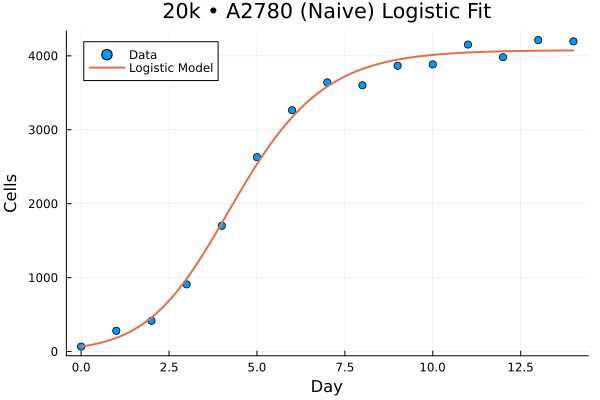

✓ Processed: A2780 (Naive) (20k) - r=1.136658, K=4077.24, v=0.624


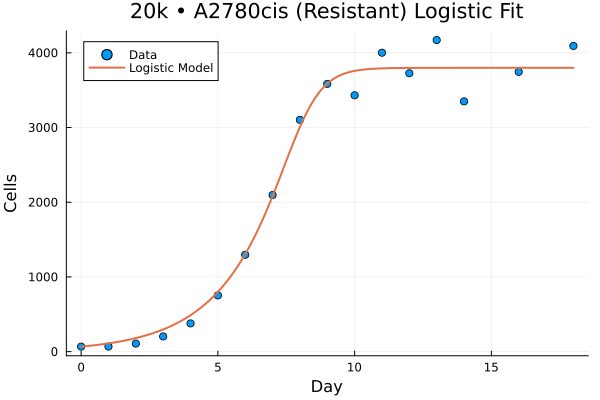

✓ Processed: A2780cis (Resistant) (20k) - r=0.496129, K=3798.89, v=3.513


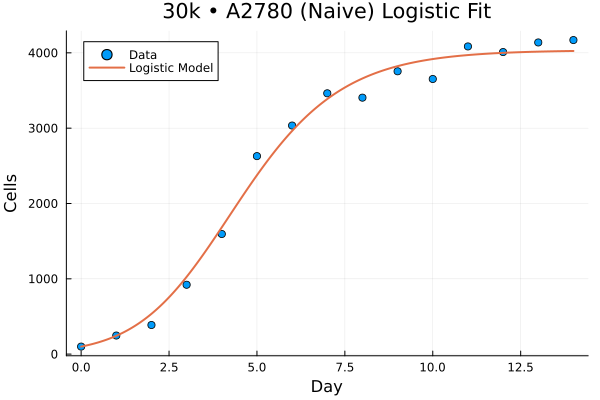

✓ Processed: A2780 (Naive) (30k) - r=1.054521, K=4035.57, v=0.575


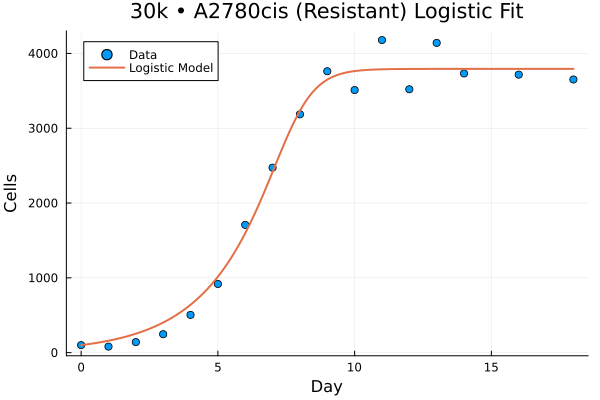

✓ Processed: A2780cis (Resistant) (30k) - r=0.464017, K=3793.35, v=3.547

Detailed Results:
4×8 DataFrame
 Row │ File                         Density  CellLine    r         K        v         SSR        BIC     
     │ String                       String   String      Float64   Float64  Float64   Float64    Float64 
─────┼───────────────────────────────────────────────────────────────────────────────────────────────────
   1 │ A2780Naive_day_averages.csv  20k      A2780Naive  1.13666   4077.24  0.624115  1.65077e5  139.169
   2 │ A2780cis_day_averages.csv    20k      A2780cis    0.496129  3798.89  3.51263   6.24822e5  177.48
   3 │ A2780Naive_day_averages.csv  30k      A2780Naive  1.05452   4035.57  0.574839  3.04802e5  147.754
   4 │ A2780cis_day_averages.csv    30k      A2780cis    0.464017  3793.35  3.54678   5.42629e5  175.223

✓ Results exported to: c:\Users\elbak\Documents\GitHub\CancerGrowthDynamics\Modeling_Approaches/01_mechanical_manual\Untreated MonoCulture\untreated_monocul

In [5]:
# batch_untreated_monoculture.jl

using CSV
using DataFrames
using Printf
using .Main: FitResult, load_day_averages, infer_density, fit_logistic, plot_data_and_fit

# If you `include("fitting_core.jl")` in a fresh Julia session, all needed
# symbols (FitResult, load_day_averages, infer_density, fit_logistic, plot_data_and_fit)
# will be in Main. Then you can run this script.

# -------------------------
# 1) Locate expected day-average CSVs
# -------------------------

# Navigate to project root (go up 2 levels from notebook directory)
project_root = dirname(dirname(pwd()))

roots = [
    joinpath(project_root, "Processed_Datasets", "Untreated MonoCulture", "20k", "Averages"),
    joinpath(project_root, "Processed_Datasets", "Untreated MonoCulture", "30k", "Averages"),
]

# Expected files for verification in each root
expected_files = [
    "A2780Naive_day_averages.csv",
    "A2780cis_day_averages.csv",
]

files = String[]
for r in roots
    if isdir(r)
        println("Checking directory: $r")
        for expected_file in expected_files
            full_path = joinpath(r, expected_file)
            if isfile(full_path)
                push!(files, full_path)
                println("  ✓ Found: $expected_file")
            else
                @warn "  ✗ Missing: $expected_file"
            end
        end
    else
        @warn "Directory not found: $r"
    end
end

if isempty(files)
    @warn "No day averages CSVs found under Untreated MonoCulture"
else
    println("\nProcessing $(length(files)) day-average files...")
end

# -------------------------
# 2) Fit logistic model per file
# -------------------------
results = DataFrame(
    File=String[],
    Density=String[],
    CellLine=String[],
    r=Float64[],
    K=Float64[],
    v=Float64[],
    SSR=Float64[],
    BIC=Float64[],
)


for f in files
    try
        x, y, yerr = load_day_averages(f)
        den = infer_density(f)

        fr, sol, stats = fit_logistic(x, y; yerr=yerr, density=den)

        filename = basename(f)
        cell_line = split(filename, "_")[1]

        push!(results, (filename, den, cell_line, stats.r, stats.K, stats.v, stats.SSR, stats.BIC))

        cell_type = cell_line == "A2780Naive" ? "A2780 (Naive)" : "A2780cis (Resistant)"
        title_str = "$den • $cell_type Logistic Fit"

        plot_data_and_fit(x, y, sol; title_str=title_str, yerr=yerr, density=den)

        println("✓ Processed: $cell_type ($den) - r=$(round(stats.r, digits=6)), K=$(round(stats.K, digits=2)), v=$(round(stats.v, digits=3))")
    catch e
        @warn "Failed on $(basename(f)): $e"
    end
end

# -------------------------
# 3) Export and summary
# -------------------------

println("\nDetailed Results:")
println(results)

# Export results to CSV in current working directory
output_dir = joinpath(pwd(), "outputs", "csv")
output_file = joinpath(output_dir, "untreated_monoculture_logistic_parameters.csv")
CSV.write(output_file, results)
println("\n✓ Results exported to: ", output_file)

# Print comprehensive summary for all 4 datasets
println("\n" * "="^60)
println("COMPREHENSIVE SUMMARY OF r AND K VALUES")
println("="^60)
println("All 4 datasets (both cell lines × both thresholds):")
println()

for density in ["20k", "30k"]
    println("$density Threshold:")
    println("-" ^ 20)
    for cell_line in ["A2780Naive", "A2780cis"]
        row = filter(r -> r.Density == density && r.CellLine == cell_line, results)
        cell_type = cell_line == "A2780Naive" ? "A2780 (Naive)" : "A2780cis (Resistant)"

        if nrow(row) > 0
            r_val = row[1, :r]
            k_val = row[1, :K]
            v_val = row[1, :v]
            @printf("  %s: r = %.6f day⁻¹, K = %.2f cells, v = %.3f\n",
        cell_type, r_val, k_val, v_val)
        else
            println("  $cell_type: Data not found")
        end
    end
    println()
end

println("Day 0 cell counts used:")
println("  20k seeding density: 67 cells   # calculated by hand from plate setup")
println("  30k seeding density: 100 cells  # calculated by hand from plate setup")
println("  Data normalization: Applied to reduce bias toward larger values")
println("  Error bars (SEM/SD): Used for weighted fitting when available")


Notes to interpret:

v < 1 means an early saturation constant
v > 1 means a late saturation constant
v = 1 is standard logistic growth

Note naive cells have early saturation constants while resistant has late saturation constants. 